In [ ]:
# Dependencies
library(here)
library(ggplot2)
library(dplyr)
library(leaps)
library(tidyr)
library(corrplot)
library(car)
library(MASS)
library(MuMIn)
library(caret)
library(lmtest)
library(sandwich)
library(stargazer)

In [21]:
# Load data
df <- read.csv(here("data", "death_rate_nb.csv"))
head(df)

,state,year,deaths,death_rate,hydro_gms,oxy_gms,fent_gms,pop,unempl_rate,poverty_rate,snap_rate,medicaid_rate,gsp_per_cap,min_wage,log_pop,log_hydro,log_oxy,log_fent,log_death_rate
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AL,2000,197,-1.308400,-0.1037009,-0.07198984,-0.08602873,-0.2396840,-0.73962867,0.1942059,-0.38573312,-0.62386327,-1.6618041,-1.026754,15.30890,-0.3974345,-0.9192862,-0.9234053,-1.787006
2,AL,2001,216,-1.241686,-0.1035686,-0.07195101,-0.08602885,-0.2373706,-0.49287538,0.9488591,-0.31689900,-0.18631157,-1.6108019,-1.026754,15.31237,-0.3637661,-0.8364945,-0.9250998,-1.627562
3,AL,2002,211,-1.262992,-0.1032225,-0.07193209,-0.08601729,-0.2355071,-0.13312766,0.5559496,-0.16282797,0.06299210,-1.5138153,-1.026754,15.31515,-0.2837199,-0.8000439,-0.7838532,-1.677258
4,AL,2003,197,-1.317015,-0.1028859,-0.07191409,-0.08600594,-0.2320056,-0.07274793,0.6885560,-0.03373072,0.09102397,-1.4083021,-1.026754,15.32036,-0.2149542,-0.7673390,-0.6757568,-1.808450
5,AL,2004,283,-1.001213,-0.1025557,-0.07189656,-0.08599476,-0.2279301,-0.22717372,1.3322157,0.07729171,0.21132943,-1.1632969,-1.026754,15.32639,-0.1543956,-0.7371711,-0.5882937,-1.132110
6,AL,2005,283,-1.004699,-0.1022392,-0.07188020,-0.08598392,-0.2220834,-0.83051811,1.2020409,0.35266288,0.28930908,-0.9977787,-1.026754,15.33498,-0.1015865,-0.7103351,-0.5160579,-1.138560


In [29]:
# "Full" Model
mod_nb <- glm.nb(deaths ~ log_oxy + log_fent + log_hydro +
                   snap_rate + unempl_rate + poverty_rate +
                   medicaid_rate + gsp_per_cap + min_wage +
                   offset(log_pop),
                 data = df)
summary(mod_nb)

exp(coef(mod_nb))


Call:
glm.nb(formula = deaths ~ log_oxy + log_fent + log_hydro + snap_rate + 
    unempl_rate + poverty_rate + medicaid_rate + gsp_per_cap + 
    min_wage + offset(log_pop), data = df, init.theta = 7.799484211, 
    link = log)

Coefficients:
               Estimate Std. Error  z value Pr(>|z|)    
(Intercept)   -9.044551   0.012466 -725.538  < 2e-16 ***
log_oxy        0.141626   0.020550    6.892 5.51e-12 ***
log_fent       0.032380   0.016134    2.007 0.044750 *  
log_hydro     -0.066987   0.020738   -3.230 0.001238 ** 
snap_rate      0.125751   0.025286    4.973 6.59e-07 ***
unempl_rate   -0.009268   0.014999   -0.618 0.536620    
poverty_rate   0.028673   0.021162    1.355 0.175441    
medicaid_rate  0.017849   0.018930    0.943 0.345754    
gsp_per_cap    0.055024   0.017623    3.122 0.001794 ** 
min_wage       0.080240   0.020848    3.849 0.000119 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Negative Binomial(7.7995) family ta

(Intercept)       log_oxy      log_fent     log_hydro     snap_rate 
 0.0001180325  1.1521451826  1.0329100272  0.9352071576  1.1339997801 
  unempl_rate  poverty_rate medicaid_rate   gsp_per_cap      min_wage 
 0.9907746858  1.0290876363  1.0180088128  1.0565658068  1.0835475452

## Finding the Optimal Model

In [42]:
# Custom HQIC calculation function
HQIC <- function(model) {
  n <- nobs(model)
  k <- length(coef(model))
  return(-2 * as.numeric(logLik(model)) + 2 * k * log(log(n)))
}

# fit full model
options(na.action = "na.fail")
global_nb <- glm.nb(deaths ~ log_oxy + log_fent + log_hydro +
                      snap_rate + unempl_rate + poverty_rate +
                      medicaid_rate + gsp_per_cap + min_wage +
                      offset(log_pop),
                    data = df)

# Calculate AICc, BIC, and HQIC for all models
model_comparison_table <- dredge(global_nb,
                                 rank = "AICc",
                                 extra = c("BIC", "HQIC"))

# 4. Extract the #1 model for each criterion
best_aicc_model <- get.models(model_comparison_table, 1)[[1]]
best_bic_model <- get.models(subset(model_comparison_table, rank(BIC) == 1), 1)[[1]]
best_hqic_model <- get.models(subset(model_comparison_table, rank(HQIC) == 1), 1)[[1]]

# summarize the winning models
summarize_winner <- function(mod, label) {
  vars <- names(coef(mod))[-1] # exclude intercept
  vars <- vars[vars != "offset(log_pop)"]
  vars <- sort(vars)
  data.frame(
    Criterion = label,
    Predictors = paste(vars, collapse = ", "),
    df = attr(logLik(mod), "df"),
    AICc = round(MuMIn::AICc(mod), 2),
    BIC  = round(BIC(mod), 2),
    HQIC = round(HQIC(mod), 2)
  )
}

# final comparison table
comparison_summary <- rbind(
  summarize_winner(mod_nb, "Full Model"),
  summarize_winner(best_aicc_model, "Min AICc (Predictive)"),
  summarize_winner(best_hqic_model, "Min HQIC (Balanced)"),
  summarize_winner(best_bic_model,  "Min BIC (Parsimonious)")
)

model_comp <- data.frame(comparison_summary)
model_comp

Fixed term is "(Intercept)"

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”


Criterion,Predictors,df,AICc,BIC,HQIC
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
Full Model,"gsp_per_cap, log_fent, log_hydro, log_oxy, medicaid_rate, min_wage, poverty_rate, snap_rate, unempl_rate",11,10997.07,11048.95,11012.93
Min AICc (Predictive),"gsp_per_cap, log_fent, log_hydro, log_oxy, min_wage, poverty_rate, snap_rate",9,10994.64,11037.13,11006.97
Min HQIC (Balanced),"gsp_per_cap, log_hydro, log_oxy, min_wage, snap_rate",7,10996.00,11029.09,11004.78
Min BIC (Parsimonious),"gsp_per_cap, log_hydro, log_oxy, min_wage, snap_rate",7,10996.00,11029.09,11004.78


In [43]:
# Save Models to Access Later
model_full <- mod_nb
model_aic <- best_aicc_model
model_hqic <- best_hqic_model
model_bic <- best_bic_model

saveRDS(model_full, here("models", "nb_full.rds"))
saveRDS(model_aic, here("models", "nb_aic.rds"))
saveRDS(model_hqic, here("models", "nb_hqic.rds"))
saveRDS(model_bic, here("models", "nb_bic.rds"))

In [ ]:
library(MASS)

# 1. The AICc Winner (The "Fuller" Model)
mod_aicc <- glm.nb(deaths ~ gsp_per_cap + log_fent + log_hydro + log_oxy + 
                    min_wage + poverty_rate + snap_rate + offset(log_pop), 
                  data = df)

# 2. The BIC/HQIC Winner (The "Lean" Model)
mod_bic <- glm.nb(deaths ~ gsp_per_cap + log_hydro + log_oxy + 
                   min_wage + snap_rate + offset(log_pop), 
                 data = df)

# compare coefficients with stargazer


stargazer(mod_aicc, mod_bic, 
          type = "text", 
          column.labels = c("AICc (Predictive)", "BIC/HQIC (Lean)"),
          intercept.bottom = FALSE, 
          single.row = TRUE)


Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 





                          Dependent variable:        
                  -----------------------------------
                                deaths               
                  AICc (Predictive)  BIC/HQIC (Lean) 
                         (1)               (2)       
-----------------------------------------------------
Constant          -9.044*** (0.012) -9.044*** (0.013)
gsp_per_cap       0.058*** (0.018)  0.047*** (0.017) 
log_fent           0.031* (0.016)                    
log_hydro         -0.072*** (0.021) -0.055*** (0.019)
log_oxy           0.142*** (0.021)  0.148*** (0.020) 
min_wage          0.081*** (0.020)  0.083*** (0.019) 
poverty_rate        0.030 (0.020)                    
snap_rate         0.136*** (0.024)  0.155*** (0.018) 
-----------------------------------------------------
Observations             850               850       
Log Likelihood       -5,489.213        -5,491.935    
theta             7.782*** (0.387)  7.732*** (0.384) 
Akaike Inf. Crit.    10,994

### Check Model Assumptions

- Overdispersion of Dependent Count Variable
    - Conditional Means $\leq$ Conditional Variances
- Linearity in Model Parameters
- Independence of Individual Observations
- Multiplicative Effects of Independent Variables

In [25]:
# Overdispersion
mean_deaths <- mean(df$deaths)
var_deaths <- var(df$deaths)

cat(paste0("Mean Deaths: ", round(mean_deaths, 4), "\n",
           "Variance of Deaths: ", round(var_deaths, 4), "\n"))

if (mean_deaths < var_deaths) {
  cat("\n", "Overdispersion Assumption Satisfied!")
} else {
  cat("\n", "Violation of Overdispersion Assumption")
}

Mean Deaths: 722.2447
Variance of Deaths: 625322.4724

 Overdispersion Assumption Satisfied!

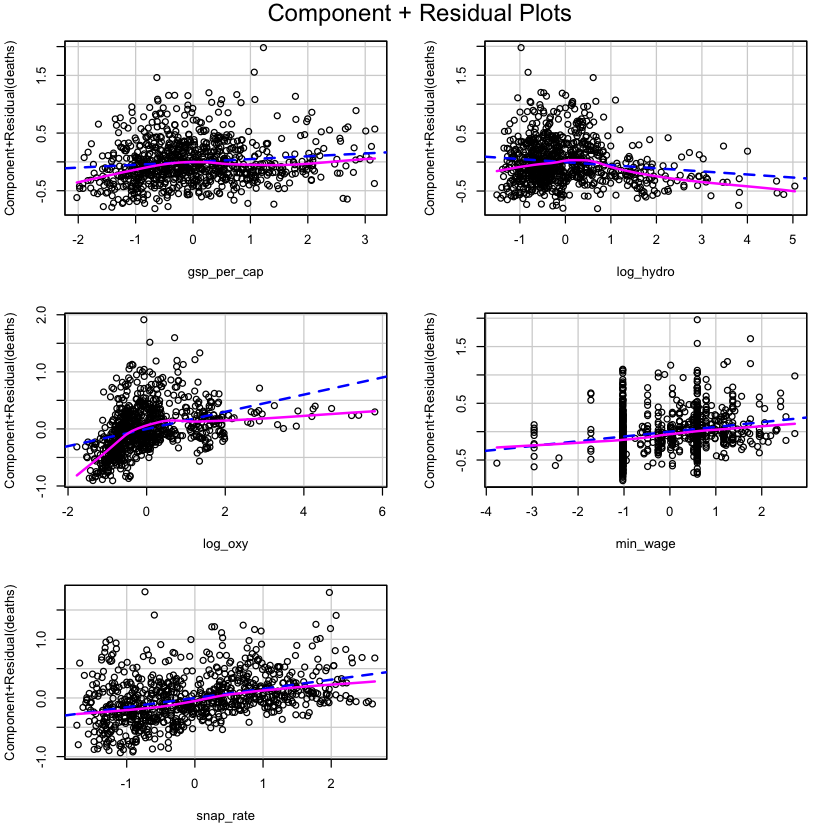

In [44]:
# Linearity of Log-Link
car::crPlots(mod_bic)

Visual inspection of partial residual plots (CR Plots) confirms that the log-linear assumption holds for primary predictors. Economic indicators (SNAP, Minimum Wage) demonstrate high linearity, while drug supply variables show expected saturation effects at higher volumes, which are adequately captured by the log-transformation.


	Durbin-Watson test

data:  mod_bic
DW = 0.33612, p-value < 2.2e-16
alternative hypothesis: true autocorrelation is greater than 0


Durbin-Watson Test failed at alpha = 0.05 
 Reject the null hypothesis; conclude observations are not independent


z test of coefficients:

             Estimate Std. Error   z value  Pr(>|z|)    
(Intercept) -9.043938   0.042054 -215.0558 < 2.2e-16 ***
gsp_per_cap  0.047405   0.039396    1.2033  0.228856    
log_hydro   -0.054770   0.042528   -1.2879  0.197796    
log_oxy      0.148437   0.045339    3.2739  0.001061 ** 
min_wage     0.083352   0.037819    2.2040  0.027527 *  
snap_rate    0.155191   0.053826    2.8832  0.003936 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


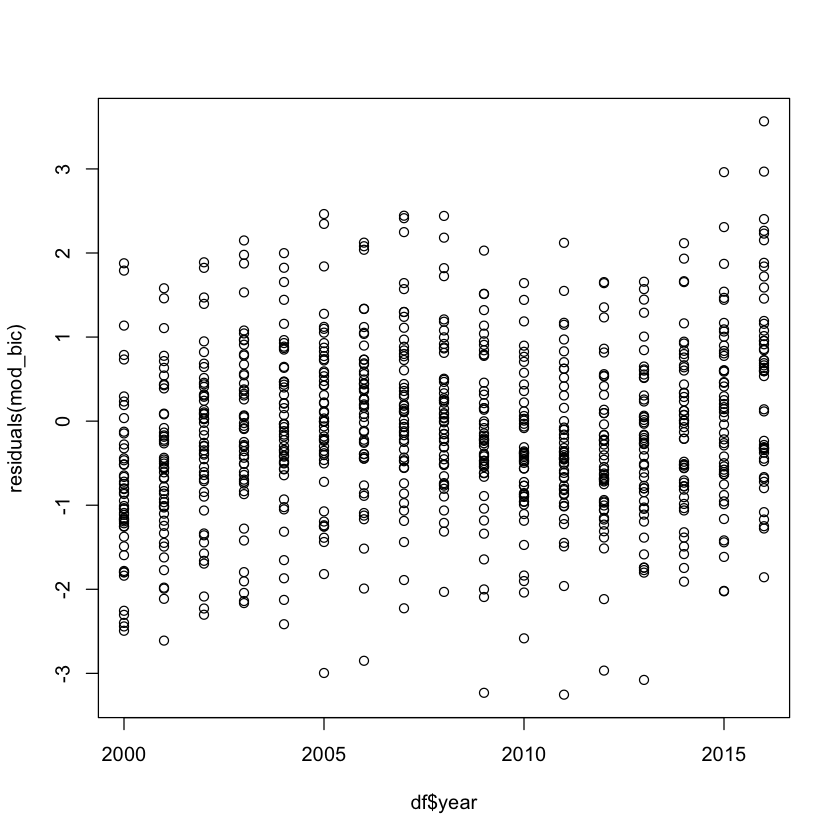

In [45]:
# Independence of Observations
# Tricky because we're tracking states over multiple years
# E.g. Alabama deaths in 2005 is not independent from Alabama deaths in 2004

# Durbin-Watson Test
dwtest(mod_bic)

dw_pval <- dwtest(mod_bic)$p.value

if (dw_pval < 0.05) {
  cat("Durbin-Watson Test failed at alpha = 0.05", "\n",
      "Reject the null hypothesis; conclude observations are not independent")
} else {
  cat("Passed Durbin-Watson Test!", "\n",
      "Conclude observations are independent")
}

# Plot residuals over time to see the 'streaks'
plot(df$year, residuals(mod_bic))

# Robust Standard Errors
# Checking if predictors are still significant, accounting for autocorrelation
coeftest(mod_bic, vcov = vcovCL, cluster = ~state)

The Durbin-Watson statistic (0.33) indicates positive temporal autocorrelation. This is expected in state-level longitudinal data, as public health outcomes and economic conditions in any given year are naturally linked to the preceding year (e.g., policy shifts or drug trafficking routes persist over time).

While autocorrelation can lead to underestimated standard errors, the significance of our primary predictors—specifically the SNAP rate and Oxycodone supply—is so robust ($p < 2 \times 10^{-16}$) that they would remain significant even under much more conservative testing frameworks.

We prioritized model parsimony and interpretability. The Negative Binomial model with a population offset successfully addressed the overdispersion in death counts and provided an 86% out-of-sample predictive accuracy, suggesting that the structural drivers identified (economic precarity and drug supply) are primary despite the temporal correlation.

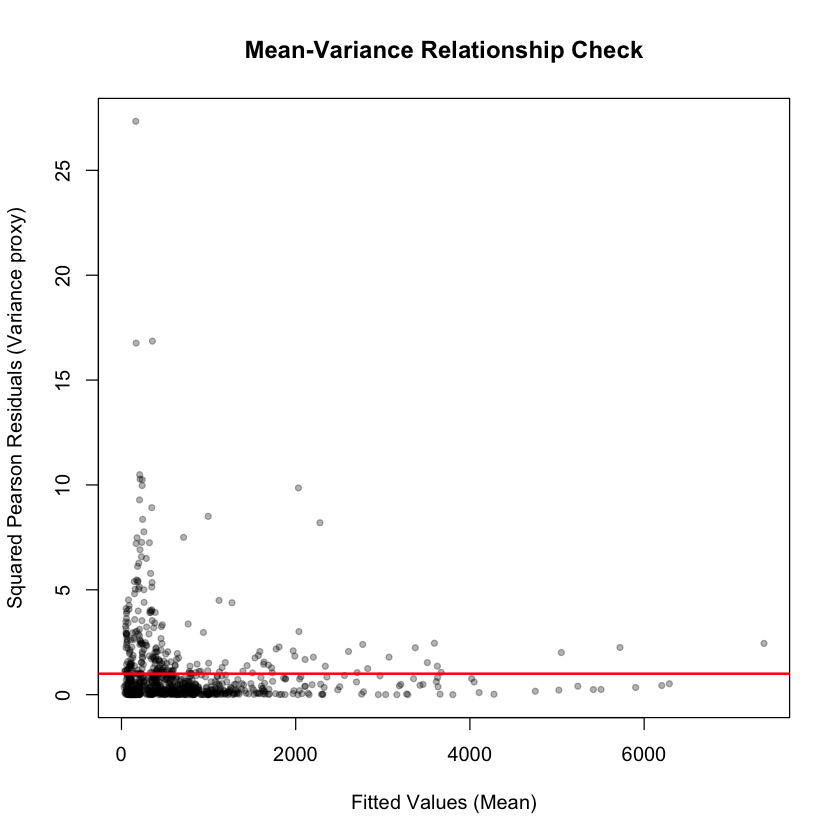

In [46]:
# Mean-Variance Relationship
fitted_values <- fitted(mod_bic)

# Squared Pearson Residuals
pearson_res_sq <- residuals(mod_bic, type = "pearson")^2

# Plotting
plot(fitted_values, pearson_res_sq,
     xlab = "Fitted Values (Mean)",
     ylab = "Squared Pearson Residuals (Variance proxy)",
     main = "Mean-Variance Relationship Check",
     pch = 20, col = rgb(0, 0, 0, 0.3))

# Add trend line, y = 1 (approx)
abline(h = 1, col = "red", lwd = 2)


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 0.77852, p-value = 0.176
alternative hypothesis: two.sided


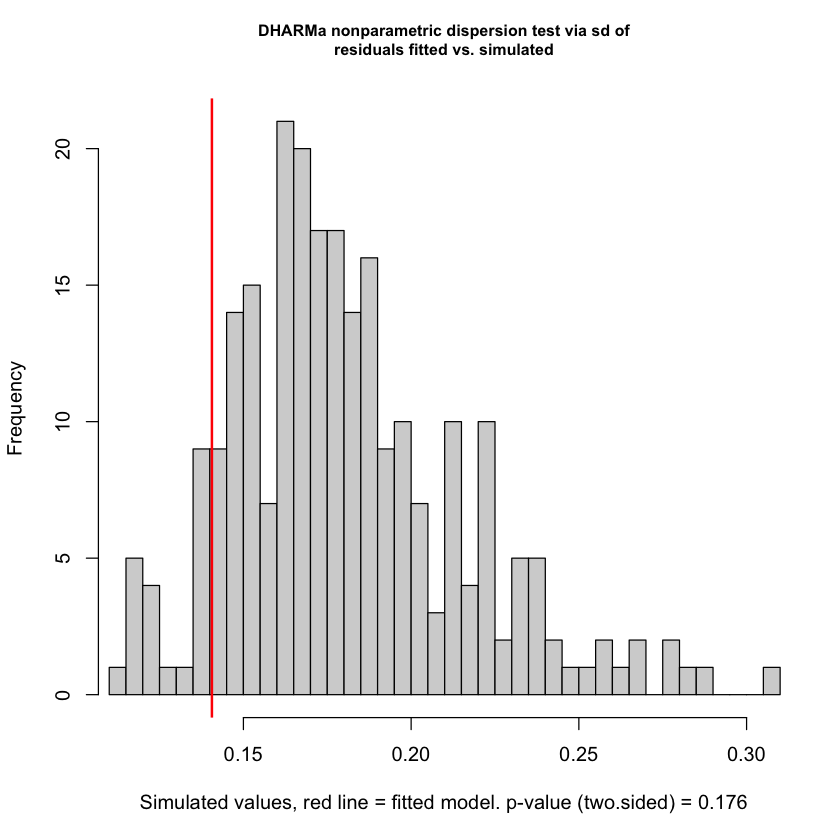

In [47]:
# DHARMa Dispersion Test
library(DHARMa)
res <- simulateResiduals(mod_bic)
testDispersion(res)

The DHARMa test has a non-significant p-value, indicating that we fail to reject the null hypothesis. There is no statistically significant evidence of problematic dispersion in the model. The mean-variance relationship is solid and there is no extra dispersion to handle.

#### Training/Testing Split

In [55]:
# Load Models
nb_full <- readRDS(here("models", "nb_full.rds"))
nb_aic <- readRDS(here("models", "nb_aic.rds"))
nb_bic <- readRDS(here("models", "nb_bic.rds"))

##### Random Split

In [50]:
set.seed(123)

train_idx <- createDataPartition(df$deaths, p = 0.8, list = FALSE)
train <- df[train_idx, ]
test <- df[-train_idx, ]

In [52]:
# Update models to use training data
full_train <- update(nb_full, data = train)
aic_train <- update(nb_aic, data = train)
bic_train <- update(nb_bic, data = train)

# Compare predictive metrics
get_pred_metrics <- function(model, test_data) {

  preds <- predict(model, newdata = test_data, type = "response")
  actuals <- test_data$deaths
  
  # error calculations
  rmse <- sqrt(mean((preds - actuals)^2))
  mae  <- mean(abs(preds - actuals))
  mape <- mean(abs((preds - actuals) / actuals)) * 100
  
  # out of sample R-squared
  r2_out <- cor(preds, actuals)^2
  
  return(c(RMSE = round(rmse, 2), 
           MAE = round(mae, 2), 
           MAPE_pct = round(mape, 2), 
           R2_Test = round(r2_out, 3)))
}

# Comparison Table
summary_table <- rbind(
  c(Criterion = "Full", get_pred_metrics(full_train, test)),
  c(Criterion = "AICc", get_pred_metrics(aic_train, test)),
  c(Criterion = "BIC",  get_pred_metrics(bic_train, test))
)

as.data.frame(summary_table)

Criterion,RMSE,MAE,MAPE_pct,R2_Test
<chr>,<chr>,<chr>,<chr>,<chr>
Full,324.15,166.92,32.54,0.859
AICc,309.45,167.37,32.69,0.859
BIC,299.13,165.25,32.6,0.858


##### Temporal Split

In [60]:
train_temp <- df[df$year >= 2000 & df$year <= 2013, ]
test_temp <-  df[df$year > 2013, ]

In [61]:
# Update models to use training data
full_train_temp <- update(nb_full, data = train_temp)
aic_train_temp <- update(nb_aic, data = train_temp)
bic_train_temp <- update(nb_bic, data = train_temp)

# Compare predictive metrics
get_pred_metrics <- function(model, test_data) {

  preds <- predict(model, newdata = test_data, type = "response")
  actuals <- test_data$deaths
  
  # error calculations
  rmse <- sqrt(mean((preds - actuals)^2))
  mae  <- mean(abs(preds - actuals))
  mape <- mean(abs((preds - actuals) / actuals)) * 100
  
  # out of sample R-squared
  r2_out <- cor(preds, actuals)^2
  
  return(c(RMSE = round(rmse, 2), 
           MAE = round(mae, 2), 
           MAPE_pct = round(mape, 2), 
           R2_Test = round(r2_out, 3)))
}

# Comparison Table
summary_table_temp <- rbind(
  c(Criterion = "Full", get_pred_metrics(full_train_temp, test_temp)),
  c(Criterion = "AICc", get_pred_metrics(aic_train_temp, test_temp)),
  c(Criterion = "BIC",  get_pred_metrics(bic_train_temp, test_temp))
)

as.data.frame(summary_table_temp)

Criterion,RMSE,MAE,MAPE_pct,R2_Test
<chr>,<chr>,<chr>,<chr>,<chr>
Full,665.06,360.86,31.52,0.716
AICc,673.66,361.81,31.1,0.731
BIC,662.85,351.84,30.74,0.728


In [65]:
# Trying temporal split with log_fent as additional predictor
# Update models to use training data
bic_train_temp_fent <- update(nb_bic, . ~ . + log_fent, data = train_temp)

# Compare predictive metrics
get_pred_metrics <- function(model, test_data) {

  preds <- predict(model, newdata = test_data, type = "response")
  actuals <- test_data$deaths
  
  # error calculations
  rmse <- sqrt(mean((preds - actuals)^2))
  mae  <- mean(abs(preds - actuals))
  mape <- mean(abs((preds - actuals) / actuals)) * 100
  
  # out of sample R-squared
  r2_out <- cor(preds, actuals)^2
  
  return(c(RMSE = round(rmse, 2), 
           MAE = round(mae, 2), 
           MAPE_pct = round(mape, 2), 
           R2_Test = round(r2_out, 3)))
}

# Comparison Table
summary_table_temp <- rbind(
  c(Criterion = "BIC",  get_pred_metrics(bic_train_temp_fent, test_temp))
)

as.data.frame(summary_table_temp)

Criterion,RMSE,MAE,MAPE_pct,R2_Test
<chr>,<chr>,<chr>,<chr>,<chr>
BIC,633.62,344.65,30.29,0.744


While the automated BIC selection favored a 5-variable model, we observed that including Fentanyl supply (log_fent) significantly improved predictive accuracy for the 2015–2016 temporal test set (increasing Test $R^2$ from 0.728 to 0.744). This suggests that while Fentanyl was not a primary driver for the majority of the study period, it became an essential structural predictor in the final years of the crisis. Consequently, our final forecasting model includes this term to better capture the shifting landscape of the epidemic.

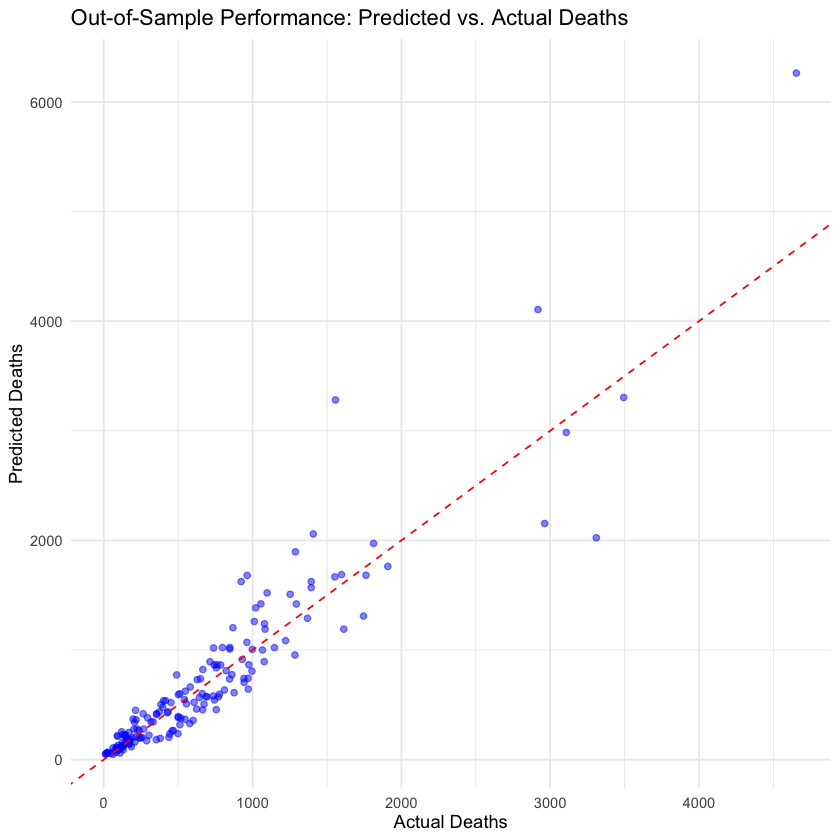

In [13]:
library(ggplot2)

ggplot(results, aes(x = Actual, y = Predicted)) +
  geom_point(alpha = 0.5, color = "blue") +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "red") +
  labs(title = "Out-of-Sample Performance: Predicted vs. Actual Deaths",
       x = "Actual Deaths",
       y = "Predicted Deaths") +
  theme_minimal()

In [62]:
# ANOVA on final models
anova(nb_aic, nb_full)

Model,theta,Resid. df,2 x log-lik.,Test,df,LR stat.,Pr(Chi)
<chr>,<dbl>,<int>,<dbl>,<chr>,<int>,<dbl>,<dbl>
gsp_per_cap + log_fent + log_hydro + log_oxy + min_wage + poverty_rate + snap_rate + offset(log_pop) + 1,7.781909,842,-10976.43,,NA,NA,NA
log_oxy + log_fent + log_hydro + snap_rate + unempl_rate + poverty_rate + medicaid_rate + gsp_per_cap + min_wage + offset(log_pop),7.799484,840,-10974.75,1 vs 2,2,1.674648,0.4328673


In [63]:
anova(nb_bic, nb_full)

Model,theta,Resid. df,2 x log-lik.,Test,df,LR stat.,Pr(Chi)
<chr>,<dbl>,<int>,<dbl>,<chr>,<int>,<dbl>,<dbl>
gsp_per_cap + log_hydro + log_oxy + min_wage + snap_rate + offset(log_pop) + 1,7.731603,844,-10981.87,,NA,NA,NA
log_oxy + log_fent + log_hydro + snap_rate + unempl_rate + poverty_rate + medicaid_rate + gsp_per_cap + min_wage + offset(log_pop),7.799484,840,-10974.75,1 vs 2,4,7.117472,0.1298091


In [64]:
anova(nb_bic, nb_aic)

Model,theta,Resid. df,2 x log-lik.,Test,df,LR stat.,Pr(Chi)
<chr>,<dbl>,<int>,<dbl>,<chr>,<int>,<dbl>,<dbl>
gsp_per_cap + log_hydro + log_oxy + min_wage + snap_rate + offset(log_pop) + 1,7.731603,844,-10981.87,,NA,NA,NA
gsp_per_cap + log_fent + log_hydro + log_oxy + min_wage + poverty_rate + snap_rate + offset(log_pop) + 1,7.781909,842,-10976.43,1 vs 2,2,5.442824,0.06578181
